# DES cluster 4x2pt + N: the cluster observables at the fiducial point

This notebook evaluates the galaxy-cluster observables of the DES Y6-like joint analysis of [arXiv:2503.13631](https://arxiv.org/abs/2503.13631) with this project's compiled Cosmolike interface. Its options mirror [EXAMPLE_EVALUATE1.yaml](EXAMPLE_EVALUATE1.yaml), which runs the likelihood `des_cluster.combo_4x2pt_N` (CL+GC in the paper): cluster counts, cluster lensing, cluster clustering, cluster–galaxy clustering, and the galaxy clustering of MagLim lens bins 1–3. The notebook computes each cluster observable at the fiducial point, shows the halo-model ingredients behind it, compares it with the synthetic data, varies the mass–richness relation, and ends with the $\chi^2$. [EXAMPLE_EVALUATE2.ipynb](EXAMPLE_EVALUATE2.ipynb) shows how the full 6x2pt + N data vector responds to cosmological and nuisance parameters.

### Galaxy clusters, richness and bins

A galaxy cluster is a massive dark-matter halo, roughly $10^{14}$ to $10^{15}\,M_\odot/h$, that hosts many galaxies. Its mass is not observed directly. The cluster finder measures instead the **richness** $\lambda$, a probability-weighted count of the cluster's red-sequence member galaxies, and the analysis uses richness as a noisy **mass proxy**: the mass–richness relation gives the probability distribution of $\lambda$ for a halo of mass $M$ at redshift $z$. Clusters are grouped into

- 3 redshift bins in the cluster's photometric redshift $z_\lambda$, with edges 0.2, 0.4, 0.55 and 0.65, and
- 4 richness bins, with edges 20, 30, 45, 60 and 500,

so each cluster observable is computed for $3\times4=12$ cluster samples.

### The observables

| block | observable | what it measures |
|---|---|---|
| `N` | cluster counts | the expected number of clusters of each (redshift, richness) bin in the 4143 deg² survey area: absolute numbers, not density contrasts |
| `cs` | cluster lensing, $\Sigma=Y\gamma_t$ | the tangential shear $\gamma_t(\theta)$ of background (source) galaxies around the clusters, localized by the $Y$ transform below |
| `cc` | cluster clustering, $w_{cc}(\theta)$ | the angular correlation function of the clusters, for every pair of richness bins in one redshift bin |
| `cg` | cluster–galaxy clustering, $w_{cg}(\theta)$ | the angular cross-correlation of the clusters with MagLim lens galaxies, one lens bin per cluster redshift bin |
| `gg` | galaxy clustering, $w_{gg}(\theta)$ | the angular correlation function of the MagLim lens galaxies, the DES lens sample selected with a redshift-dependent magnitude limit |

### The $Y$ transform and its zero last bin

The tangential shear at projected radius $R$ responds to all the mass enclosed within $R$, including the cluster core, which is hard to model. The data vector therefore stores the localized statistic $\Sigma=Y\gamma_t$ (eq. 15 of the paper; [Park, Rozo & Krause 2021](https://arxiv.org/abs/2004.07504)). $Y$ is a fixed $20\times20$ matrix acting on the angular bins of $\gamma_t$. It turns the shear profile into the difference $\Sigma_m(R)-\Sigma_m(R_{\max})$ of the projected mass density $\Sigma_m$ between $R$ and the outermost radius $R_{\max}$, divided by the critical surface density of the cluster–source geometry, so $\Sigma$ is dimensionless like $\gamma_t$. This difference depends only on the mass profile between $R$ and $R_{\max}$. At $R=R_{\max}$ it subtracts a value from itself: the last angular bin of every cluster-lensing row is exactly zero, and the mask always removes it.

### The joint data vector and the synthetic data

Both cluster likelihoods read one joint vector of 2812 entries, with the blocks in the order `ss`, `gs`, `gg`, `cg`, `N`, `cc`, `cs`: cosmic shear (400 entries), galaxy–galaxy lensing (480), galaxy clustering (120), cluster–galaxy clustering (240), counts (12), cluster clustering (600) and cluster lensing (960). The two likelihoods differ only in the scale-cut mask: the 4x2pt + N mask used here keeps 889 entries and removes `ss` and `gs` entirely; the 6x2pt + N mask keeps 1429.

No public DES cluster data vector exists, so the data are synthetic: the data vector is this model at the fiducial point of Table I of the paper, without noise, and the covariance is an analytic Gaussian covariance. The data points in the figures therefore lie on the model curves by construction, and their error bars are the square roots of the covariance diagonal. Nothing here is a DES measurement.

### How the notebook drives Cosmolike

The project's notebook wrappers (`interface/cosmolike_des_cluster_notebook_wrappers.py`, imported as `nw`) repeat the likelihood's steps on every call: run CAMB, hand the power spectra, the growth factor and the distances to the interface (`set_cosmology`), set the nuisance parameters, and read an observable. The [project README](README.md#des_cluster_wrappers) lists the wrappers and the plotting functions.

The sections follow the order of a likelihood evaluation: the setup and the CAMB import; the likelihood options; the fiducial point; the initialization of Cosmolike and the layout of the joint data vector. Then come the observables (the counts, the halo-model ingredients, cluster lensing, $w_{cc}$, $w_{cg}$ and their Limber spectra), the response to the mass–richness relation, and the $\chi^2$.

## Units, bins and plotting conventions

- **Angles.** The real-space statistics use 20 logarithmic angular bins between 2.5 and 250 arcmin; the wrappers return the bin centers $\theta$ in arcmin.
- **Bin indices.** Arrays and the `richness` and `pairs` arguments count bins from 0; panel labels and legends count from 1.
- **Array layouts.** Each wrapper returns the angle (or multipole) axis first, then the bins:

| observable | wrapper | array axes |
|---|---|---|
| counts | `nw.N_cluster` | [richness, cluster z] |
| $\gamma_t$, $\Sigma$ | `nw.gamma_t_cluster`, `nw.sigma_cluster` | [$\theta$, richness, cluster z, source] |
| $w_{cc}$ | `nw.w_cc` | [$\theta$, richness 1, richness 2, cluster z] |
| $w_{cg}$ | `nw.w_cg` | [$\theta$, richness, cluster z, lens]; zero outside the dataset's pairs |
| $C_\ell^{cs}$, $C_\ell^{cc}$, $C_\ell^{cg}$ | `nw.C_cs_tomo_limber`, ... | the layouts above, with $\ell$ first |

- **Units.** Counts are numbers of clusters in the survey area. Shears, $\Sigma$, the correlation functions $w$ and the spectra $C_\ell$ are dimensionless. Halo masses are $M_{200m}$ in $M_\odot/h$: the mass inside the radius within which the mean density is 200 times the mean matter density of the Universe. Wavenumbers $k$ are in $h/{\rm Mpc}$, number densities in $(h/{\rm Mpc})^3$ and power spectra in $({\rm Mpc}/h)^3$. Inside the C library lengths are measured in units of $c/H_0$; the wrappers convert.
- **Plots without a reference** draw the absolute value of the quantity on a logarithmic axis, one panel per redshift bin or bin pair, with the richness bins drawn as line styles inside each panel (the counts put the richness on the x axis instead). `rescale = 1` multiplies each panel by its own power of ten, $\alpha$, so that all panels share one y axis.
- **Plots with a reference** (a `*_ref` argument) draw the fractional difference, value/reference $-\,1$; `ylim` then gives the band of value/reference, drawn as `ylim` $-\,1$.
- **Data points** are the synthetic data with $\pm1\sigma$ error bars, drawn only where the scale cuts keep them. A point survives when $\theta>R/\chi(\bar z)$, with $\chi(\bar z)$ the comoving distance to the mean redshift of the bin at the fiducial cosmology and $R=2$ (cluster lensing), 8 ($w_{cg}$, $w_{gg}$) or 16 ($w_{cc}$) comoving Mpc/$h$. The mask also removes a (cluster bin, source bin) pair of cluster lensing entirely when the upper edge of the cluster bin lies above the mean redshift of the source bin, so that panel has no data points.

The cluster plotting functions of `plot_datavectors_cluster` (`pdc`) form one family per block:

| function | one panel per | curves inside a panel |
|---|---|---|
| `pdc.plot_N_cluster` | cluster redshift bin, with the richness on the x axis | one staircase per model |
| `pdc.plot_gammat_cluster_tomo`, `pdc.plot_sigma_cluster_tomo`, `pdc.plot_C_cs_tomo_limber` | (cluster z bin, source bin) pair: columns are cluster z bins, rows source bins | the richness bins |
| `pdc.plot_wcc_tomo`, `pdc.plot_C_cc_tomo_limber` | cluster redshift bin | the richness pairs (by default the auto pairs) |
| `pdc.plot_wcg_tomo`, `pdc.plot_C_cg_tomo_limber` | (cluster z bin, lens bin) pair of the dataset | the richness bins |

`richness` selects the richness bins to draw, and `pairs` the richness pairs of $w_{cc}$ (the panels of $w_{cg}$), counted from 0. `data` overlays the synthetic data and skips the NaN entries that the mask removes.

## Setup: threads, imports and figure style

The next cell sets the number of OpenMP threads for Cosmolike's C loops. `OMP_NUM_THREADS` keeps a value exported in the shell before Jupyter started and defaults to 4 otherwise; the wrappers hand it to `ci.set_omp_threads` before each calculation. The cell imports the compiled interface `cosmolike_des_cluster_interface` as `ci` and fixes the figure style. `text.usetex = True` typesets every figure label with LaTeX, which needs a LaTeX installation (the comment in the cell lists the packages). The inline figure resolution is moderate because the notebook is stored with its outputs.

In [1]:
%matplotlib inline
import sys, platform, os
# threads of cosmolike's OpenMP regions; a value already set in the shell wins
os.environ.setdefault('OMP_NUM_THREADS', '4')
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import cosmolike_des_cluster_interface as ci
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 15
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# Resolution of the inline figures. The notebook is committed with its
# outputs, so a moderate value keeps the file at a few MB; for sharper
# figures on screen raise it, or add the line
# %config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.dpi'] = 80
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# text.usetex = True typesets all figure text with LaTeX. It needs the system packages
# texlive-latex-base, texlive-latex-extra, texlive-fonts-recommended, dvipng, ghostscript
# and cm-super; set it to False when they are missing.
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster


## CAMB and the shared notebook packages

Cosmolike does not solve the Boltzmann equations itself. The linear and nonlinear matter power spectra, the growth factor and the comoving distances come from CAMB through `cnu.get_camb_cosmology` of the shared package `cosmolike_notebook_utils`. The notebook never calls CAMB directly: a wrapper calls it when a cosmology is first requested and keeps the last result, so repeated calls at one cosmology cost one CAMB run. The CAMB import below only reports which CAMB build Python loads; `get_camb_cosmology` imports CAMB at its first call and receives this same module, because Python keeps a single copy of each imported module.

The cell also imports the shared package as `cnu`, its cluster plotting module `plot_datavectors_cluster` as `pdc` (it is not part of the `cnu` namespace), and the project wrappers as `nw`.

In [2]:
# IMPORT CAMB
# The directory below names a Linux x86-64 CAMB build. When it does not exist (for
# example on macOS), Python skips that sys.path entry and imports the CAMB installed in
# Cocoa's Python environment; the printed path shows which CAMB was loaded.
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))
# the cluster data-vector plots live in their own module of that package
# (it is not part of the cnu.* namespace): call them as pdc.plot_N_cluster,
# pdc.plot_sigma_cluster_tomo, pdc.plot_wcc_tomo, pdc.plot_wcg_tomo, ...
from cosmolike_notebook_utils import plot_datavectors_cluster as pdc

# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/des_cluster/interface):
# the cluster observables, the halo-model ingredients, and the chi2
# wrappers every notebook of this project shares
import cosmolike_des_cluster_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb


Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster/interface/cosmolike_des_cluster_notebook_wrappers.py


## The likelihood options

The values below repeat the likelihood block of `EXAMPLE_EVALUATE1.yaml`. `nw.configure` stores them in the wrappers before the initialization reads them, and it rejects an unknown option name. The cluster switches choose the model:

| option | value | meaning |
|---|---|---|
| `cluster_kernel_mode` | 0 | radial weight of each cluster bin in the two-point functions: the comoving volume times the selection kernel $\langle\phi_i\vert z\rangle$, as in the DES analysis; 1 would also weight by the cluster abundance |
| `cluster_selection_model` | 2 | the scale-dependent selection bias $B(\theta)$ of eq. 23, applied to the data vector: richness-selected clusters sit preferentially in filaments along the line of sight, which boosts their lensing and clustering signals |
| `cluster_ytransform` | 1 | cluster lensing stored as $\Sigma=Y\gamma_t$; 0 would store $\gamma_t$ |
| `cluster_include_ia` | 1 | intrinsic alignment of the source galaxies in the two-halo cluster-lensing term |
| `cluster_magnification` | $-2$ | coefficient $C_c$ of the lensing magnification of the cluster sample (eq. 28); 0 switches it off |
| `cluster_hmf_alpha_mode` | 0 | amplitude of the Tinker et al. (2010) mass function fixed at 0.368 at every redshift, as in the DES analysis |

The other options: `integration_accuracy = 1` selects the quadrature level these redshift distributions need (the MagLim tails reach $z\approx3$); `lmax` is the largest multipole of the internal $C_\ell$ tables summed into the real-space statistics; `non_linear_emul = 2` takes the nonlinear matter power spectrum from CAMB's halofit, a fitting formula calibrated on N-body simulations; `IA_model = 0` selects the nonlinear-alignment (NLA) model of intrinsic alignments, whose amplitude is zero at the fiducial point.

In [3]:
# The options of EXAMPLE_EVALUATE1.yaml: CL+GC (4x2pt + N) on the synthetic
# DES Y6-like data = cluster counts, cluster lensing, w_cc, w_cg and the
# galaxy clustering of MagLim bins 1-3. For CL+3x2pt (EXAMPLE_EVALUATE2.yaml)
# set CLprobe = "6x2pt_N" and data_file = "des_cluster_y6_6x2ptN.dataset"
CLprobe = "4x2pt_N"

path = "../../external_modules/data/des_cluster"
data_file = "des_cluster_y6_4x2ptN.dataset"

non_linear_emul = 2
IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)
lmax = 75000
integration_accuracy = 1

cluster_kernel_mode = 0       # 0 = volume only (what DES ran), 1 = abundance weighted
cluster_selection_model = 2   # 0 = none, 1 = Y1 (mass dependent), 2 = Y6 (scale dependent, eq 23)
cluster_ytransform = 1        # 1 = Sigma = Y gamma_t (eq 15), 0 = gamma_t
cluster_include_ia = 1
cluster_magnification = -2.0  # C_c (eq 28)
cluster_hmf_alpha_mode = 0    # 0 = Tinker alpha = 0.368 at every z (what DES ran)

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(path=path,
             data_file=data_file,
             lmax=lmax,
             integration_accuracy=integration_accuracy,
             non_linear_emul=non_linear_emul,
             IA_model=IA_model,
             IA_redshift_evolution=IA_redshift_evolution,
             IA_code=IA_code,
             cluster_kernel_mode=cluster_kernel_mode,
             cluster_selection_model=cluster_selection_model,
             cluster_ytransform=cluster_ytransform,
             cluster_include_ia=cluster_include_ia,
             cluster_magnification=cluster_magnification,
             cluster_hmf_alpha_mode=cluster_hmf_alpha_mode)

## The fiducial point and the nuisance parameters

The wrappers module holds the fiducial point as plain constants: Table I of the paper, the point of the synthetic data vector. Every wrapper falls back to these values, so a call names only what it changes, for example `nw.N_cluster(omegam=0.31)`. The cosmology has $w=-1$ and one massive neutrino with $\Omega_\nu h^2=0.00083$ ($m_\nu\approx0.077$ eV).

The cluster nuisance parameters form two vectors.

- `MOR` = [$\ln\lambda_0$, $A_\lambda$, $\sigma_{\rm int}$, $B_\lambda$], the lognormal mass–richness relation of eqs. 18–19. The mean log-richness of a halo of mass $M$ at redshift $z$ is
$$\langle\ln\lambda\,|\,M,z\rangle=\ln\lambda_0+A_\lambda\ln\frac{M}{M_{\rm piv}}+B_\lambda\ln\frac{1+z}{1+z_{\rm piv}},\qquad M_{\rm piv}=5\times10^{14}\,M_\odot/h,\quad 1+z_{\rm piv}=1.45,$$
and $\ln\lambda$ scatters around it with the variance $\sigma^2_{\rm int}+(\bar\lambda-1)/\bar\lambda^2$, where $\bar\lambda=e^{\langle\ln\lambda\rangle}$: an intrinsic scatter plus a Poisson term.
- `SEL` = [$b_{s1}$, $b_{s2}$, $r_0$, $s_3$], the selection bias of eq. 23, $B(\theta)=b_{s1}+b_{s2}\exp[-\theta\chi(\bar z)/r_0]$, with $r_0$ in comoving Mpc/$h$ and $\chi(\bar z)$ the comoving distance to the mean redshift of the cluster bin. $s_3$, the power of an extra factor $(1+\bar z)/1.45$, is zero in the paper's model.

The galaxy and source nuisance parameters (shifts of the photometric-redshift distributions, linear galaxy biases, shear calibration, intrinsic alignment) also take their Table I values.

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_des_cluster_notebook_wrappers.py): Table I of
# arXiv 2503.13631, the point of the synthetic data vector
# (scripts/make_synthetic_data.py). Override any value per call
# instead, e.g. nw.N_cluster(omegam=0.31) or nw.N_cluster(MOR=[...]).
from cosmolike_des_cluster_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    DES_CL_LNLAMBDA0, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA,
    DES_CL_BS1, DES_CL_BS2, DES_CL_R0, DES_CL_BSZ)
print("cosmology: As_1e9 = %g, ns = %g, H0 = %g, omegab = %g, omegam = %g, mnu = %.5f eV, w = %g"
      %(As_1e9, ns, H0, omegab, omegam, mnu, w))
print("mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda):", nw.MOR_FID)
print("selection bias (b_s1, b_s2, r_0 [Mpc/h], s3):", nw.SELECTION_FID)

cosmology: As_1e9 = 2.19, ns = 0.96859, H0 = 69, omegab = 0.048, omegam = 0.3, mnu = 0.07719 eV, w = -1
mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda): [4.26, 0.943, 0.15, 0.207]
selection bias (b_s1, b_s2, r_0 [Mpc/h], s3): [1.1, 0.2, 30.0, 0.0]


## Initialize Cosmolike: probes, bins, redshift distributions and data

`nw.init_cosmolike` runs the likelihood's initialization once, in the likelihood's order: the probes of `CLprobe`, the angular binning, the lens and source redshift distributions, the survey area, the cluster model switches, the richness bins, the selection kernels $\langle\phi_i|z\rangle$ (the probability that a cluster at true redshift $z$ is assigned to observed redshift bin $i$) and the (cluster redshift bin, lens bin) pairs of $w_{cg}$. With `with_data = True` it also loads the mask, the synthetic data vector and its covariance, which the data overlays and the $\chi^2$ need. `CLprobe` decides only which blocks enter the masked data vector; every observable wrapper works with any probe choice.

The cell then reads the bins back from the dataset file and prepares legend labels and line colors. Cluster redshift bin $i$ is paired with MagLim lens bin $i$ in $w_{cg}$.

In [5]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike: the init
# chain of the likelihood, likelihood/_cosmolike_prototype_base.py).
# with_data = True also loads the mask, the synthetic data vector and its
# covariance (the data overlays and the chi2 below need them)
ini = nw.init_cosmolike(CLprobe=CLprobe, with_data=True)

# bins of the dataset
dataset = nw.dataset_info()
richness_edges = dataset["richness_edges"]
zbin_edges = dataset["cluster_zbin_edges"]
nrichness = len(richness_edges) - 1
ncluster = len(zbin_edges) - 1
nsource = dataset["source_ntomo"]
nlens = dataset["lens_ntomo"]
# Legend labels and line colors, one per bin: each list comprehension formats
# one label per bin; get_cmap(name)(values) gives one RGBA color per value in [0, 1].
richness_label = [r"$\lambda \in [%g, %g)$"%(richness_edges[i], richness_edges[i+1]) for i in range(nrichness)]
zbin_label = [r"$z_\lambda \in [%g, %g)$"%(zbin_edges[i], zbin_edges[i+1]) for i in range(ncluster)]
richness_color = plt.get_cmap("viridis")(np.linspace(0.0, 0.85, nrichness))
zbin_color = plt.get_cmap("plasma")(np.linspace(0.1, 0.75, ncluster))
print("richness bins:", richness_edges, " cluster z bins:", zbin_edges)
print("source bins:", nsource, " lens bins:", nlens, " survey area [deg2]:", dataset["survey_area_deg2"])
# (cluster z bin, lens bin) pairs of w_cg
print("w_cg pairs (cluster z bin, lens bin):", np.array(ci.get_cg_redshift_bins()).astype(int).tolist())

richness bins: [ 20.  30.  45.  60. 500.]  cluster z bins: [0.2  0.4  0.55 0.65]
source bins: 4  lens bins: 6  survey area [deg2]: 4143.0
w_cg pairs (cluster z bin, lens bin): [[0, 0], [1, 1], [2, 2]]


## The joint data vector and its scale cuts

`ci.compute_data_vector_cluster_sizes` and `ci.compute_data_vector_cluster_starts` give the length and the first index of each block in the 2812-entry vector, and `ci.get_mask_cluster` the mask (1 keeps an entry). Inside each block the angular bins of one tomographic row are consecutive; the `cs` block, for example, is ordered [(cluster z, source) pair][richness][$\theta$]. The cell prints how many entries of each block the 4x2pt + N mask keeps.

`nw.data_cluster_blocks` puts the cluster blocks of the synthetic data and of their errors back into the array layouts of the model wrappers, with NaN where the mask removes an entry, so the plotting functions can draw model and data in the same panels and skip the removed points.

In [6]:
# The joint data vector (ss, gs, gg, cg, N, cc, cs) of the dataset: the
# synthetic data, its 1-sigma errors, and the mask, in the full layout
dv_names = ["ss", "gs", "gg", "cg", "N", "cc", "cs"]
dv_sizes = np.array(ci.compute_data_vector_cluster_sizes())
dv_starts = np.array(ci.compute_data_vector_cluster_starts())
# dv_block maps each block name to the slice of its entries in the joint vector.
dv_block = {name: slice(dv_starts[i], dv_starts[i] + dv_sizes[i]) for i, name in enumerate(dv_names)}
dv_mask = np.array(ci.get_mask_cluster()).astype(bool)
for name in dv_names:
    print("%2s: %4d entries, %4d after the scale cuts"%(name, dv_sizes[dv_names.index(name)], dv_mask[dv_block[name]].sum()))

# The cluster blocks of the data and of their 1-sigma errors, put back
# into the array layouts of the model wrappers (N: [richness, cluster z],
# cs: [theta, richness, cluster z, source], cc: [theta, richness 1,
# richness 2, cluster z], cg: [theta, richness, cluster z, lens]).
# Entries the scale cuts remove are NaN: the plotting functions skip them
data, error = nw.data_cluster_blocks()

ss:  400 entries,    0 after the scale cuts
gs:  480 entries,    0 after the scale cuts
gg:  120 entries,   31 after the scale cuts
cg:  240 entries,  128 after the scale cuts
 N:   12 entries,   12 after the scale cuts
cc:  600 entries,  230 after the scale cuts
cs:  960 entries,  488 after the scale cuts


## What one wrapper call does: CAMB, `set_cosmology` and the nuisance setters

Every observable wrapper (`nw.N_cluster`, `nw.sigma_cluster`, `nw.w_cc`, ...) sets the complete state of the interface before it reads its observable, so no call depends on which wrapper ran before it. One call runs these steps:

1. **CAMB.** `cnu.get_camb_cosmology` runs CAMB for the requested cosmology, unless the previous call used the same one. It returns the natural logarithm of the linear and nonlinear matter power spectra in $({\rm Mpc}/h)^3$ on a grid of $\log_{10}k$ ($k$ in $h/{\rm Mpc}$) and redshift; the growth factor $G(z)=D(z)\,(1+z)$ on a dense redshift grid, divided by its value at the last redshift of the power-spectrum grid; the comoving distance $\chi(z)$ in Mpc/$h$; $\Omega_\nu h^2$; and the linear power spectrum of cold dark matter plus baryons, which the halo model of the clusters uses.
2. **Accuracy and binning.** `ci.init_accuracy_boost` and `ci.init_binning` reset the numerical accuracy and the angular bins.
3. **`ci.set_cosmology`** hands $\Omega_m$, $\Omega_b$, $H_0$ and these tables to the C library.
4. **Nuisance setters**, in the likelihood's order: the lens galaxies (`set_point_mass`, `set_nuisance_bias`, `set_nuisance_clustering_photoz`), the sources (`set_nuisance_shear_calib`, `set_nuisance_shear_photoz`, `set_nuisance_ia`) and the clusters (`set_nuisance_cluster_mor` with `MOR`, `set_nuisance_cluster_selection` with `SEL`). A vector that the call does not name takes its fiducial value.
5. **The observable**, for example `ci.N_cluster_tomo()` for the counts or `ci.w_sigma_cluster_tomo()` for cluster lensing.

The counts below come from the notebook's first wrapper call, which includes its first CAMB run.

## Cluster number counts $N$ per richness and redshift bin

The expected number of clusters in redshift bin $i$ and richness bin $\alpha$ is (eq. 16)
$$N_{i\alpha}=\Omega_s\int dz\,\frac{dV}{dz\,d\Omega}\,\langle\phi_i|z\rangle\,n_\alpha(z),\qquad n_\alpha(z)=\int d\ln M\,\frac{dn}{d\ln M}\,P(\alpha\,|\,M,z),$$
where $\Omega_s$ is the survey solid angle, $dV/(dz\,d\Omega)$ the comoving volume per unit redshift and solid angle, $dn/d\ln M$ the Tinker et al. halo mass function, and $P(\alpha|M,z)$ the probability that a halo of mass $M$ has its observed richness in bin $\alpha$. The counts are absolute numbers: they grow with the survey volume and are not divided by a mean, unlike the density contrasts behind the correlation functions.

The table prints the counts; the figure has one panel per cluster redshift bin with the richness on the x axis, the model as a staircase and the synthetic data with $\pm1\sigma$ errors.

In [7]:
# counts[richness bin, cluster z bin] (eq 16 of arXiv 2503.13631)
counts = nw.N_cluster()
print("expected counts (rows = richness bins, columns = cluster z bins):")
# One line per richness bin: join() places the counts of the cluster z bins side by side.
for nl in range(nrichness):
    print("  lambda in [%3g, %3g): "%(richness_edges[nl], richness_edges[nl+1]) + "  ".join("%9.2f"%x for x in counts[nl]))
print("  total per z bin:       " + "  ".join("%9.2f"%x for x in counts.sum(axis=0)))

expected counts (rows = richness bins, columns = cluster z bins):
  lambda in [ 20,  30):   3789.11    4600.88    3458.85
  lambda in [ 30,  45):   1702.23    1904.92    1337.80
  lambda in [ 45,  60):    549.33     562.15     366.30
  lambda in [ 60, 500):    450.26     397.11     230.29
  total per z bin:         6490.92    7465.06    5393.24


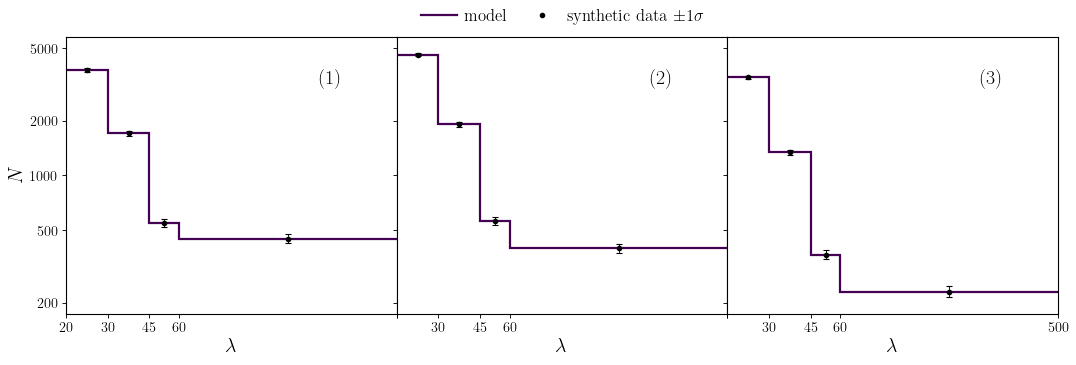

In [8]:
# model counts against the synthetic data: one panel per cluster z bin
# (the label in each panel), the richness on the x axis
pdc.plot_N_cluster(N = [counts],
                   richness_edges = richness_edges,
                   data = (data["N"], error["N"]),
                   datalabel = r"synthetic data $\pm 1\sigma$",
                   legend = ["model"],
                   cmap = "viridis",
                   linewidth = [2.0],
                   figsize = (16, 4.5),
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

## Halo-model ingredients: $P(\lambda\,{\rm bin}|M,z)$, $n_{\rm cl}(z)$, $b_{\rm cl}(z)$

The cluster predictions are built from the halo model. The next four figures show its ingredients for each richness bin.

1. $P(\alpha|M,z)$, the probability that a halo of mass $M$ at redshift $z$ is observed in richness bin $\alpha$, from the lognormal mass–richness relation (solid lines $z=0.3$, dashed $z=0.6$). Their sum, "any bin", falls below one at low mass, where most halos have $\lambda<20$.
2. The comoving number density $n_{\rm cl}(z)$ of the clusters of each richness bin, and their richness-weighted linear bias $b_{\rm cl}(z)$, the average of the halo bias $b_h(M,z)$ over the halos of the bin (eq. 21). The bias relates the large-scale density contrast of the clusters to that of the matter, $\delta_{\rm cl}=b\,\delta_m$; richer clusters are more massive, rarer and more strongly biased. Dotted lines mark the edges of the cluster redshift bins.
3. The selection kernels $\langle\phi_i|z\rangle$ of the three redshift bins and the normalized true-redshift distributions $n_i(z)\propto(dV/dz)\,\langle\phi_i|z\rangle$: redshift errors make neighboring bins overlap in true redshift. With the volume kernel of `cluster_kernel_mode = 0`, these distributions are the same for every richness bin.
4. The one-halo cluster–matter power spectrum $P^{1h}_{cm}(k)$ at $z=0.3$ (eq. 22): the Navarro–Frenk–White (NFW) mass profile of the clusters' own halos, which sets cluster lensing on small scales.

The $n_{\rm cl}$ and $b_{\rm cl}$ tables cover the redshift range of the cluster bins and are zero outside it.

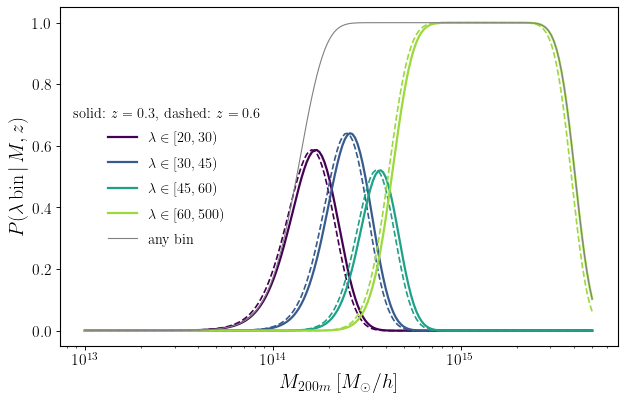

In [9]:
# Probability that a halo of mass M lands in each richness bin: the
# lognormal mass-observable relation of eqs (18)-(19)
M = np.logspace(13.0, 15.7, 200)   # Msun/h (M200m)
z_P = np.array([0.3, 0.6])
P = nw.prob_richness_bin_given_m(M, z_P)   # (n_M, n_z, n_richness)

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
for nl in range(nrichness):
    ax.plot(M, P[:, 0, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
    ax.plot(M, P[:, 1, nl], color=richness_color[nl], linewidth=1.5, linestyle="dashed")
ax.plot(M, P[:, 0, :].sum(axis=1), color="gray", linewidth=1.0, label="any bin")
ax.set_xscale("log")
ax.set_xlabel(r"$M_{200m}\ [M_\odot/h]$", fontsize=18)
ax.set_ylabel(r"$P(\lambda\,{\rm bin}\,|\,M, z)$", fontsize=18)
ax.tick_params(labelsize=14)
ax.legend(loc="center left", fontsize=13, frameon=False, title=r"solid: $z = %g$, dashed: $z = %g$"%tuple(z_P), title_fontsize=13)
plt.show()

n_cl and b_cl tabulated for z in [0.158, 0.708]


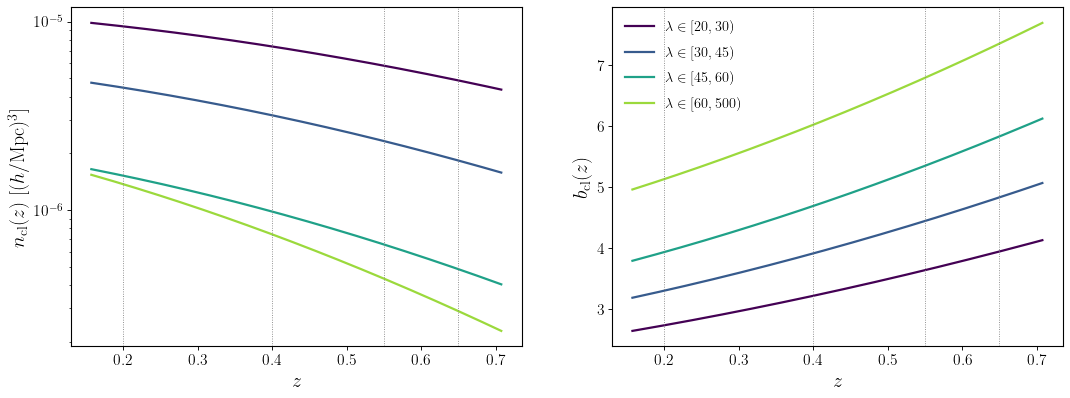

In [10]:
# Number density and bias of the clusters of each richness bin. The tables
# of the C code cover the redshift support of the cluster bins and return
# zero outside it, so the curves are drawn where n_cl > 0.
z = np.linspace(0.1, 0.8, 281)
ncl = nw.ncl_richness(z)   # (n_z, n_richness) in (h/Mpc)^3
bcl = nw.bcl_richness(z)   # (n_z, n_richness)
inside = ncl[:, 0] > 0
print("n_cl and b_cl tabulated for z in [%.3f, %.3f]"%(z[inside].min(), z[inside].max()))

fig, axs = plt.subplots(1, 2, figsize=(16, 5.5))
for nl in range(nrichness):
    axs[0].plot(z[inside], ncl[inside, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
    axs[1].plot(z[inside], bcl[inside, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$n_{\rm cl}(z)\ [(h/{\rm Mpc})^3]$", fontsize=18)
axs[1].set_ylabel(r"$b_{\rm cl}(z)$", fontsize=18)
for ax in axs:
    for edge in zbin_edges:
        ax.axvline(edge, color="gray", linewidth=0.8, linestyle="dotted")
    ax.set_xlabel(r"$z$", fontsize=18)
    ax.tick_params(labelsize=14)
axs[1].legend(loc="upper left", fontsize=13, frameon=False)
plt.show()

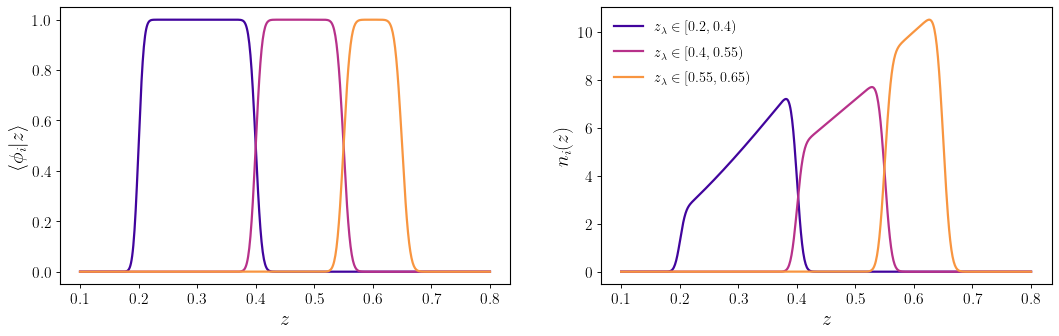

In [11]:
# Redshift selection of the cluster bins: the kernels <phi_i|z> (the
# probability that a cluster at true redshift z lands in z_lambda bin i)
# and the normalized true-redshift distributions n_i(z) ~ dV/dz <phi_i|z>
z = np.linspace(0.1, 0.8, 701)
phi = nw.phi_cluster(z)   # (n_z, n_cluster)
nz = nw.nz_cluster(z)     # (n_z, n_cluster, n_richness); volume kernel: the same for every richness bin

fig, axs = plt.subplots(1, 2, figsize=(16, 4.5))
for ni in range(ncluster):
    axs[0].plot(z, phi[:, ni], color=zbin_color[ni], linewidth=2.0, label=zbin_label[ni])
    axs[1].plot(z, nz[:, ni, 0], color=zbin_color[ni], linewidth=2.0, label=zbin_label[ni])
axs[0].set_ylabel(r"$\langle \phi_i | z \rangle$", fontsize=18)
axs[1].set_ylabel(r"$n_i(z)$", fontsize=18)
for ax in axs:
    ax.set_xlabel(r"$z$", fontsize=18)
    ax.tick_params(labelsize=14)
axs[1].legend(loc="upper left", fontsize=13, frameon=False)
plt.show()

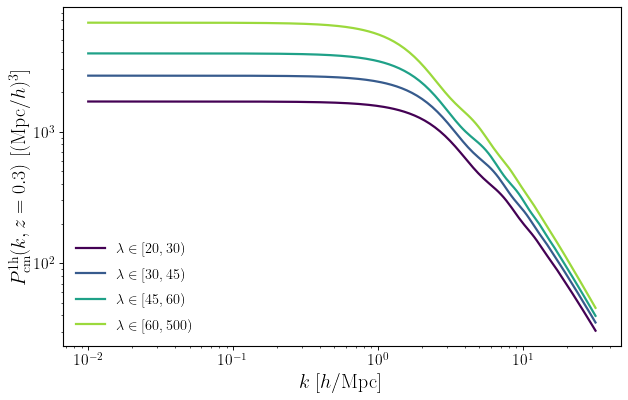

In [12]:
# One-halo cluster-matter power spectrum of each richness bin (eq 22): the
# NFW profile of the clusters' own halos, the small-scale part of cluster lensing
k = np.logspace(-2, 1.5, 200)   # h/Mpc
p1h = nw.pcm_1h_richness(k, [0.3])   # (n_k, n_z, n_richness) in (Mpc/h)^3

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
for nl in range(nrichness):
    ax.plot(k, p1h[:, 0, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$", fontsize=18)
ax.set_ylabel(r"$P^{\rm 1h}_{\rm cm}(k, z = 0.3)\ [({\rm Mpc}/h)^3]$", fontsize=18)
ax.tick_params(labelsize=14)
ax.legend(loc="lower left", fontsize=13, frameon=False)
plt.show()

## Cluster lensing $\gamma_t(\theta)$ and $\Sigma(\theta)=Y\gamma_t$

The mass of a cluster deflects the light of galaxies behind it and stretches their images tangentially around the cluster. The mean tangential shear at angular separation $\theta$ is $\gamma_t=\Delta\Sigma(R)/\Sigma_{\rm crit}$: the excess surface density $\Delta\Sigma(R)=\bar\Sigma_m(\lt R)-\Sigma_m(R)$, the mean projected mass density inside the projected radius $R=\chi(z_c)\,\theta$ minus its value at $R$, with $z_c$ the cluster redshift, divided by the critical surface density $\Sigma_{\rm crit}=c^2D_s/(4\pi G\,D_lD_{ls})$, where $D_l$, $D_s$ and $D_{ls}$ are the angular-diameter distances to the cluster, to the source and between them. The model (eqs. 20–22) adds a two-halo term, from matter in other halos correlated with the cluster (the cluster bias times the nonlinear matter power spectrum, with cluster magnification and source intrinsic alignment), and a one-halo term, from the mass of the cluster's own halo.

The data vector holds $\Sigma=Y\gamma_t$ instead (eq. 15). The matrix $Y=2S+SD$ (called $T$ in the C code and in the code comments) combines a finite-difference derivative $D$ in $\ln\theta$ with a trapezoid integral $S$ from each bin out to the last one. It applies the identity
$$\Sigma_m(R)-\Sigma_m(R_{\max})=\int_{\ln R}^{\ln R_{\max}}d\ln R'\,\Big[2\,\Delta\Sigma(R')+\frac{d\Delta\Sigma}{d\ln R'}\Big],$$
whose right side does not depend on the mass inside $R$. Its last bin, $R=R_{\max}$, is exactly zero. $\Sigma$ also carries the selection bias $B(\theta)$ and the shear calibration $(1+m)$; the $\gamma_t$ of `nw.gamma_t_cluster` carries neither.

The three figures show $\gamma_t$, then $\Sigma$ with the synthetic data, then both for the lowest and the highest richness bin. Columns are cluster redshift bins and rows source bins; each panel is labeled (cluster bin, source bin). The scale cut keeps $R>2$ comoving Mpc/$h$, and the mask removes a (cluster bin, source bin) pair entirely when the upper edge of the cluster bin lies above the mean redshift of the source bin.

(20, 4, 3, 4)


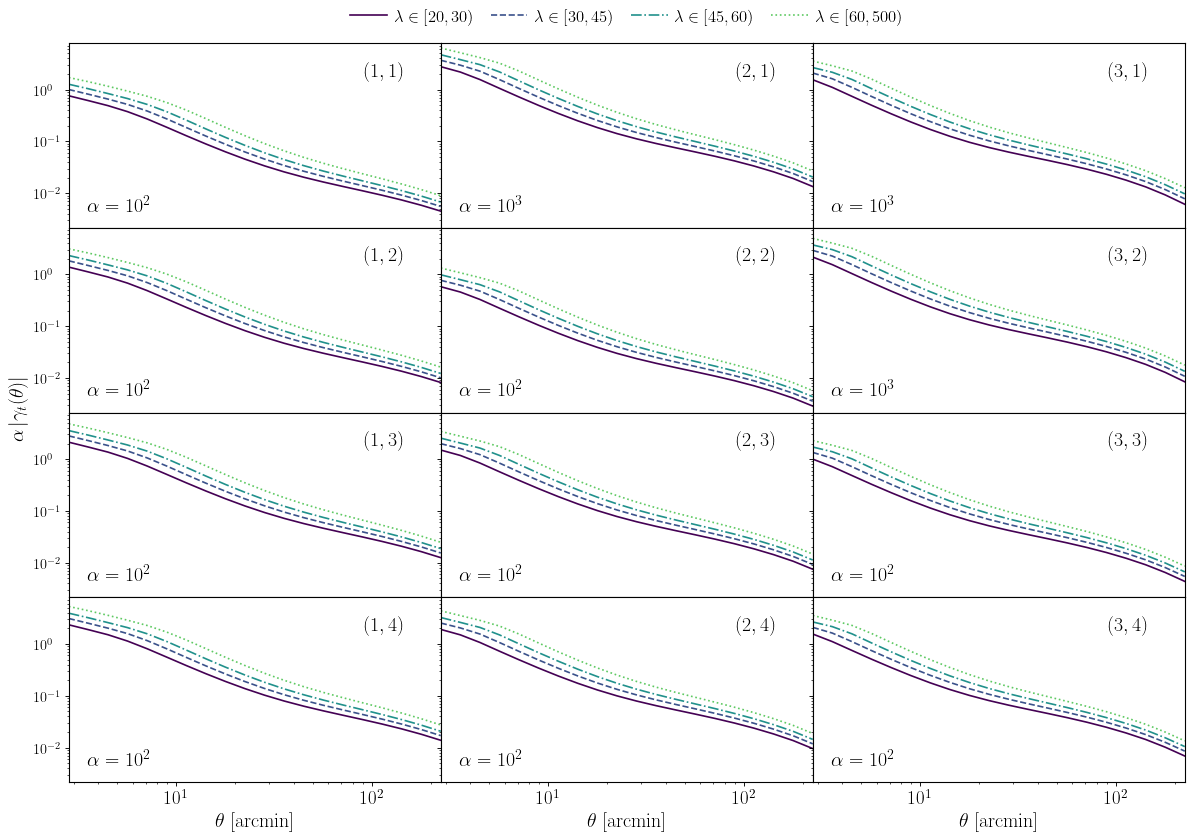

In [13]:
# gamma_t[theta, richness bin, cluster z bin, source bin]: the tangential
# shear before the Y transform, the selection bias and the shear
# calibration (the likelihood applies those on the data vector).
# Layout of the cluster lensing plots: columns = cluster z bins, rows =
# source bins, the label in each panel is (cluster z bin, source bin);
# the richness bins are the curves of a panel. rescale = 1 multiplies
# each panel by its own power of ten (alpha) so the grid shares one y axis
theta_gammat = nw.gamma_t_cluster()
print(theta_gammat[1].shape)

pdc.plot_gammat_cluster_tomo(theta_gammat = [theta_gammat],
                             richnesslabel = richness_label,
                             cmap = "viridis",
                             linewidth = [1.5],
                             figsize = (18, 12),
                             bintextsize = 18,
                             yaxislabelsize = 18,
                             xaxislabelsize = 18,
                             yaxisticklabelsize = 13,
                             xaxisticklabelsize = 17,
                             rescale = 1,
                             ydecades = 4)

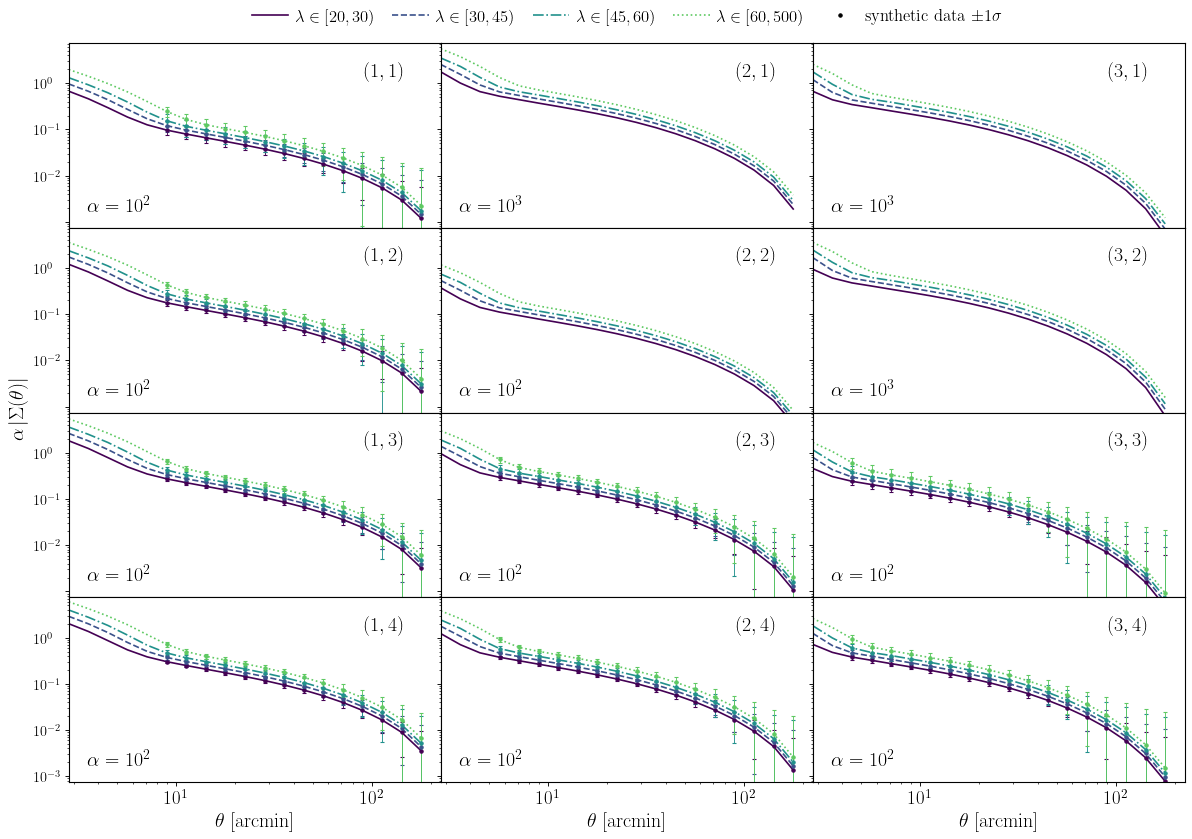

In [14]:
# What the data vector holds (the cs block): Sigma = T gamma_t, the Y
# transform of eq (15) that removes the mass enclosed below each scale,
# times the selection bias of eq (23) and the shear calibration. The last
# angular bin of Sigma is zero by construction (always masked). Points:
# the synthetic data where the scale cuts keep them (R > 2 Mpc/h comoving).
theta_sigma = nw.sigma_cluster()
theta = theta_sigma[0]

pdc.plot_sigma_cluster_tomo(theta_sigma = [theta_sigma],
                            data = (theta, data["cs"], error["cs"]),
                            datalabel = r"synthetic data $\pm 1\sigma$",
                            richnesslabel = richness_label,
                            cmap = "viridis",
                            linewidth = [1.5],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

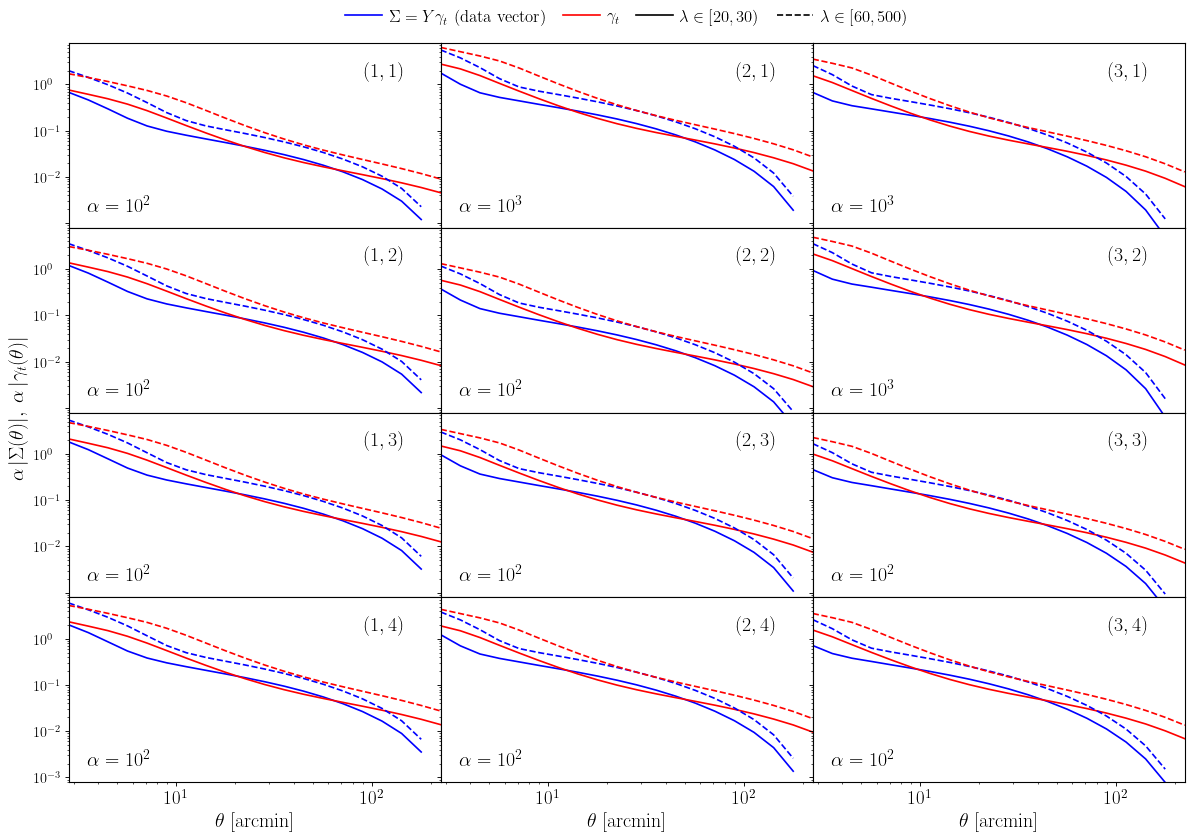

In [15]:
# Sigma against gamma_t for the lowest and the highest richness bin
# (richness counts from 0): with two entries in the list the color tells
# the entries apart and the line style the richness bins
pdc.plot_sigma_cluster_tomo(theta_sigma = [theta_sigma, theta_gammat],
                            legend = [r"$\Sigma = Y\gamma_t$ (data vector)", r"$\gamma_t$"],
                            richness = [0, nrichness-1],
                            richnesslabel = richness_label,
                            cmap = "brg",
                            linewidth = [1.5],
                            ylabel = r"$\alpha\,|\Sigma(\theta)|,\ \alpha\,|\gamma_t(\theta)|$",
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

## Cluster clustering $w_{cc}(\theta)$

$w_{cc}(\theta)$ is the excess probability, relative to a random distribution, of finding two clusters at angular separation $\theta$. The model treats each richness bin as a linearly biased tracer of the nonlinear matter density, plus the cluster magnification term. The angular spectra use the Limber approximation (eq. 10), which evaluates the three-dimensional power spectrum at $k=(\ell+1/2)/\chi$ along the line of sight. The data vector holds the 10 richness pairs $\alpha\le\beta$ of each of the 3 redshift bins (600 entries); there is no clustering between different cluster redshift bins. With `selection_bias = True` the wrapper multiplies by $B(\theta)^2$, one factor per cluster, as the data vector does; the second figure shows that factor as a ratio. The scale cut keeps $R>16$ comoving Mpc/$h$.

(20, 4, 4, 3)


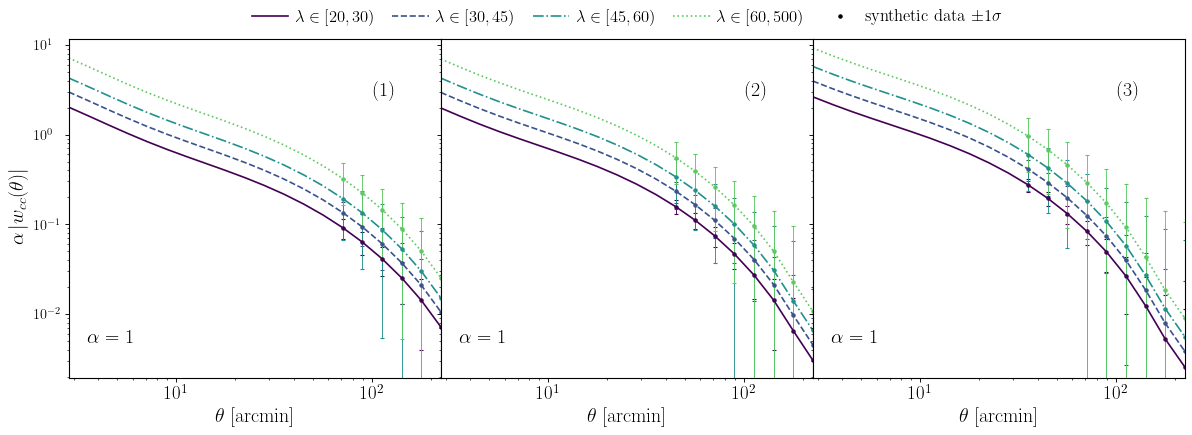

In [16]:
# w_cc[theta, richness bin 1, richness bin 2, cluster z bin]: auto z bin,
# every richness pair (symmetric). selection_bias = True multiplies by the
# selection bias squared (eq 23), as the data vector carries it. One panel
# per cluster z bin; the curves are the richness auto pairs (the default;
# pairs = [(0, 3), ...] picks any others). Points: the synthetic data
# where the scale cuts keep them (R > 16 Mpc/h comoving).
theta_wcc = nw.w_cc(selection_bias=True)
theta_wcc_nobias = nw.w_cc(selection_bias=False)
print(theta_wcc[1].shape)

pdc.plot_wcc_tomo(theta_wcc = [theta_wcc],
                  data = (theta, data["cc"], error["cc"]),
                  datalabel = r"synthetic data $\pm 1\sigma$",
                  richnesslabel = richness_label,
                  cmap = "viridis",
                  linewidth = [1.5],
                  figsize = (18, 5.5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17,
                  rescale = 1,
                  ydecades = 4)

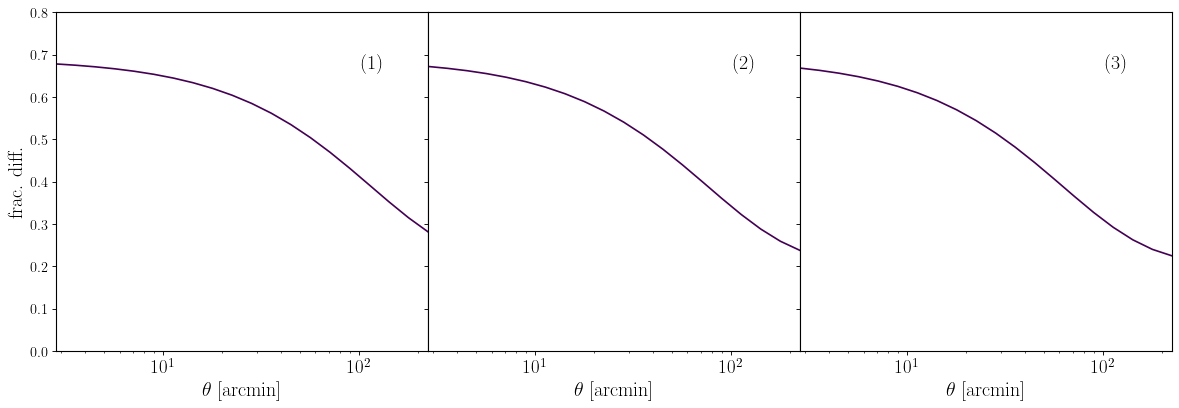

In [17]:
# What the selection bias does to w_cc: with a reference the panels show
# the fractional difference, here B(theta)^2 - 1 (ylim is the band of
# the ratio, drawn as ylim - 1). B does not depend on the richness, so
# one richness pair is enough (pairs counts the richness bins from 0)
pdc.plot_wcc_tomo(theta_wcc = [theta_wcc],
                  theta_wcc_ref = theta_wcc_nobias,
                  pairs = [(0, 0)],
                  cmap = "viridis",
                  linewidth = [1.5],
                  ylim = [1.0, 1.8],
                  figsize = (18, 5.5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

## Cluster–galaxy clustering $w_{cg}(\theta)$

$w_{cg}(\theta)$ is the angular cross-correlation of the clusters with MagLim lens galaxies. Both are modeled as linearly biased tracers of the nonlinear matter density, with a magnification term on each side. Each cluster redshift bin is paired with one lens bin (cluster bin $i$ with lens bin $i$, the `cg_lens_bins` of the dataset), so only those pairs are computed: the other entries of the returned array are zero and get no panel. With `selection_bias = True` the wrapper multiplies by one factor $B(\theta)$. The scale cut keeps $R>8$ comoving Mpc/$h$ at the mean redshift of the cluster bin.

(20, 4, 3, 6)  nonzero (cluster z bin, lens bin) pairs: [[0, 0], [1, 1], [2, 2]]


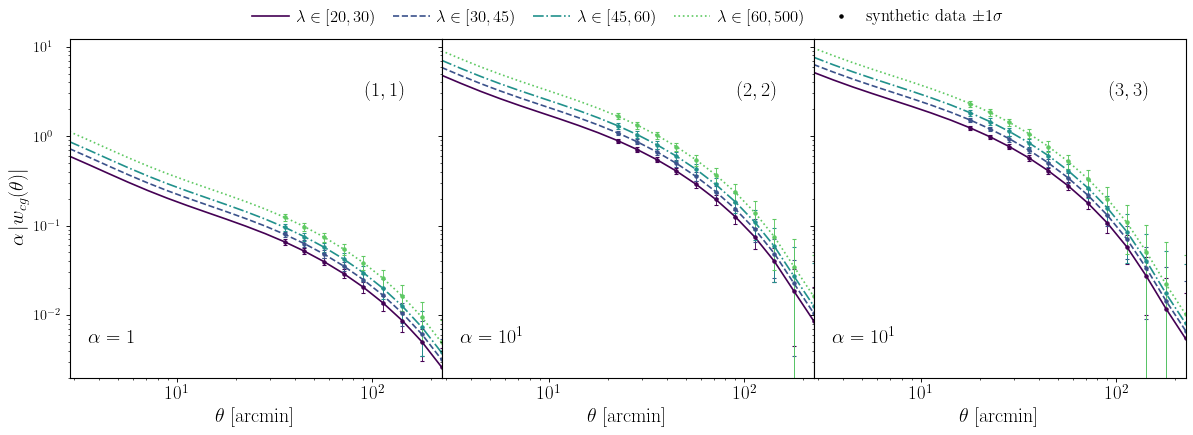

In [18]:
# w_cg[theta, richness bin, cluster z bin, lens bin]: only the (cluster z
# bin, lens bin) pairs of the dataset are filled (cg_lens_bins), the rest
# is zero, and only those pairs get a panel (the label in each panel).
# selection_bias = True multiplies by the selection bias (eq 23).
# Points: the synthetic data where the scale cuts keep them (R > 8 Mpc/h comoving).
theta_wcg = nw.w_cg(selection_bias=True)
cg_pairs = np.array(ci.get_cg_redshift_bins()).astype(int)   # row n = (cluster z bin, lens bin)
print(theta_wcg[1].shape, " nonzero (cluster z bin, lens bin) pairs:", cg_pairs.tolist())

pdc.plot_wcg_tomo(theta_wcg = [theta_wcg],
                  data = (theta, data["cg"], error["cg"]),
                  datalabel = r"synthetic data $\pm 1\sigma$",
                  richnesslabel = richness_label,
                  cmap = "viridis",
                  linewidth = [1.5],
                  figsize = (18, 5.5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17,
                  rescale = 1,
                  ydecades = 4)

## Fourier space: $C_\ell^{cs}$, $C_\ell^{cc}$, $C_\ell^{cg}$ (Limber)

The real-space statistics are projections of angular power spectra: $w(\theta)$ and $\gamma_t(\theta)$ are sums over multipoles $\ell$ of $C_\ell$ weighted by Legendre polynomials averaged over each angular bin. These are the Limber spectra described above. They are intermediate quantities: the data vector holds the real-space statistics. The figures show $|C_\ell|$ without the $\ell(\ell+1)/2\pi$ weighting; $C_\ell^{cs}$ is the spectrum behind $\gamma_t$, before the $Y$ transform and the selection bias.

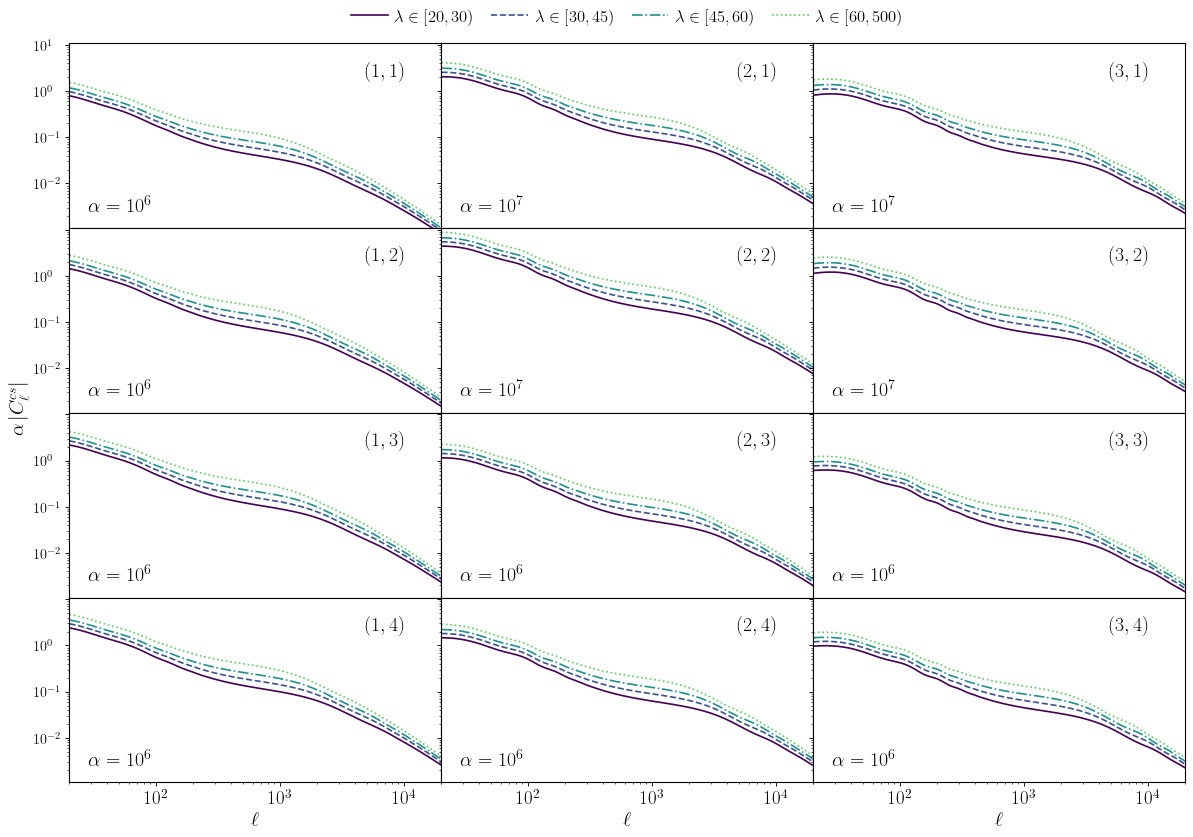

In [19]:
# The spectra behind the three real-space statistics:
# C_cs[ell, richness, cluster z, source], C_cc[ell, richness 1, richness 2,
# cluster z], C_cg[ell, richness, cluster z, lens]
ell = np.logspace(np.log10(20.0), np.log10(20000.0), 120)
C_cs = nw.C_cs_tomo_limber(ell)
C_cc = nw.C_cc_tomo_limber(ell)
C_cg = nw.C_cg_tomo_limber(ell)

pdc.plot_C_cs_tomo_limber(ell = ell,
                          C_cs = [C_cs],
                          richnesslabel = richness_label,
                          cmap = "viridis",
                          linewidth = [1.5],
                          lmin = ell[0],
                          lmax = ell[-1],
                          figsize = (18, 12),
                          bintextsize = 18,
                          yaxislabelsize = 18,
                          xaxislabelsize = 18,
                          yaxisticklabelsize = 13,
                          xaxisticklabelsize = 17,
                          rescale = 1,
                          ydecades = 4)

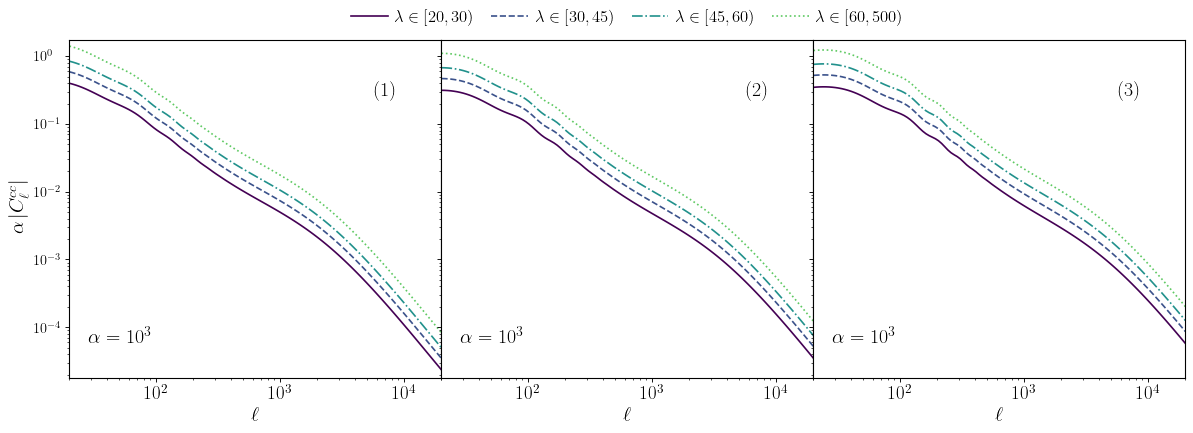

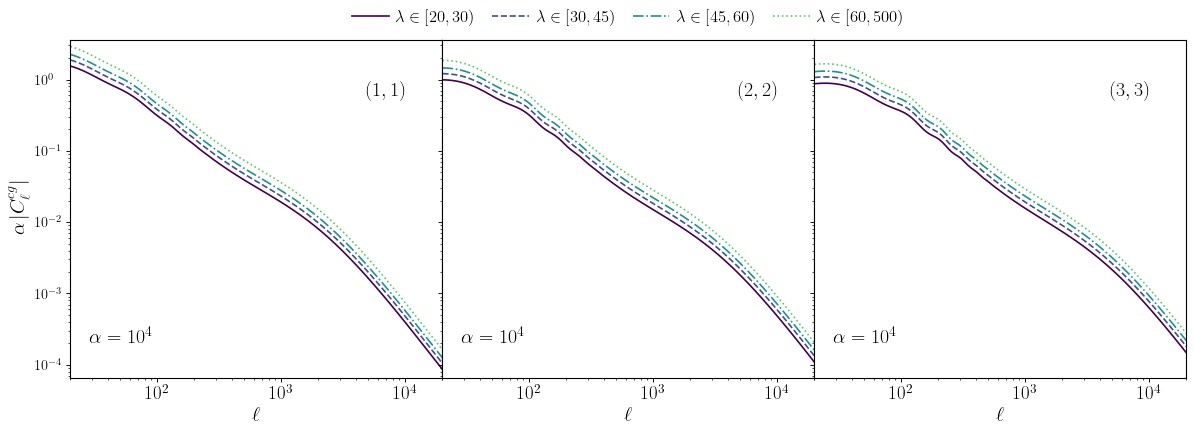

In [20]:
pdc.plot_C_cc_tomo_limber(ell = ell,
                          C_cc = [C_cc],
                          richnesslabel = richness_label,
                          cmap = "viridis",
                          linewidth = [1.5],
                          lmin = ell[0],
                          lmax = ell[-1],
                          figsize = (18, 5.5),
                          bintextsize = 18,
                          yaxislabelsize = 18,
                          xaxislabelsize = 18,
                          yaxisticklabelsize = 13,
                          xaxisticklabelsize = 17,
                          rescale = 1,
                          ydecades = 5)
pdc.plot_C_cg_tomo_limber(ell = ell,
                          C_cg = [C_cg],
                          richnesslabel = richness_label,
                          cmap = "viridis",
                          linewidth = [1.5],
                          lmin = ell[0],
                          lmax = ell[-1],
                          figsize = (18, 5.5),
                          bintextsize = 18,
                          yaxislabelsize = 18,
                          xaxislabelsize = 18,
                          yaxisticklabelsize = 13,
                          xaxisticklabelsize = 17,
                          rescale = 1,
                          ydecades = 5)

## How the mass–richness relation changes the counts and $\gamma_t(\theta)$

The next cells vary the amplitude $\ln\lambda_0$ of the mass–richness relation over five values within $\pm0.2$ of the fiducial 4.26. The cosmology stays fixed, so every call reuses one CAMB run. A larger $\ln\lambda_0$ gives every halo a larger richness, so each richness bin collects less massive and more abundant halos: the counts rise, and the lensing signal, which follows the mean mass of the bin, falls. The figures show value/reference $-\,1$ against the fiducial model, colored by $\ln\lambda_0$ (colorbar); in the $\gamma_t$ figure the line style marks the richness bin.

In [21]:
# Every wrapper takes the cosmology and the nuisance vectors as keyword
# arguments. MOR = [ln lambda_0, A_lambda, sigma_int, B_lambda]
param = np.linspace(DES_CL_LNLAMBDA0 - 0.2, DES_CL_LNLAMBDA0 + 0.2, 5)
counts_param = []
gammat_param = []
for x in param:
    MOR = [x, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]
    counts_param.append(nw.N_cluster(MOR=MOR))
    gammat_param.append(nw.gamma_t_cluster(MOR=MOR))

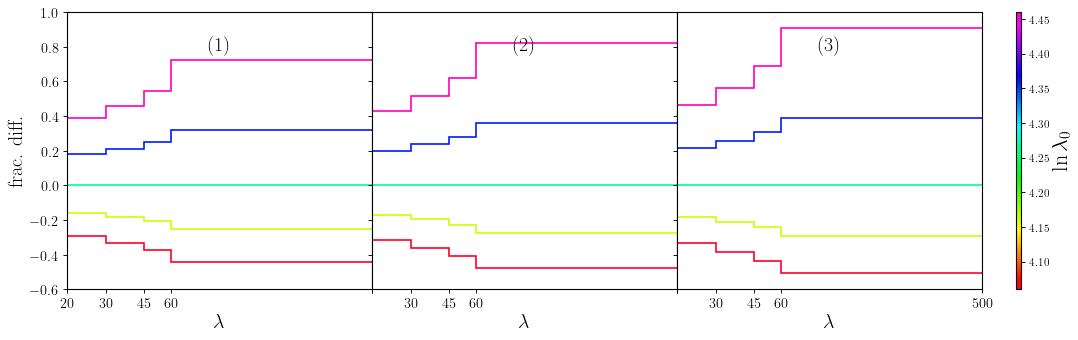

In [22]:
# Plot the ratio over the fiducial model: with a list of models, the color
# follows the parameter value (the colorbar)
pdc.plot_N_cluster(N = counts_param,
                   N_ref = counts,
                   param = param,
                   colorbarlabel = r"$\ln\lambda_0$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 2.0],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

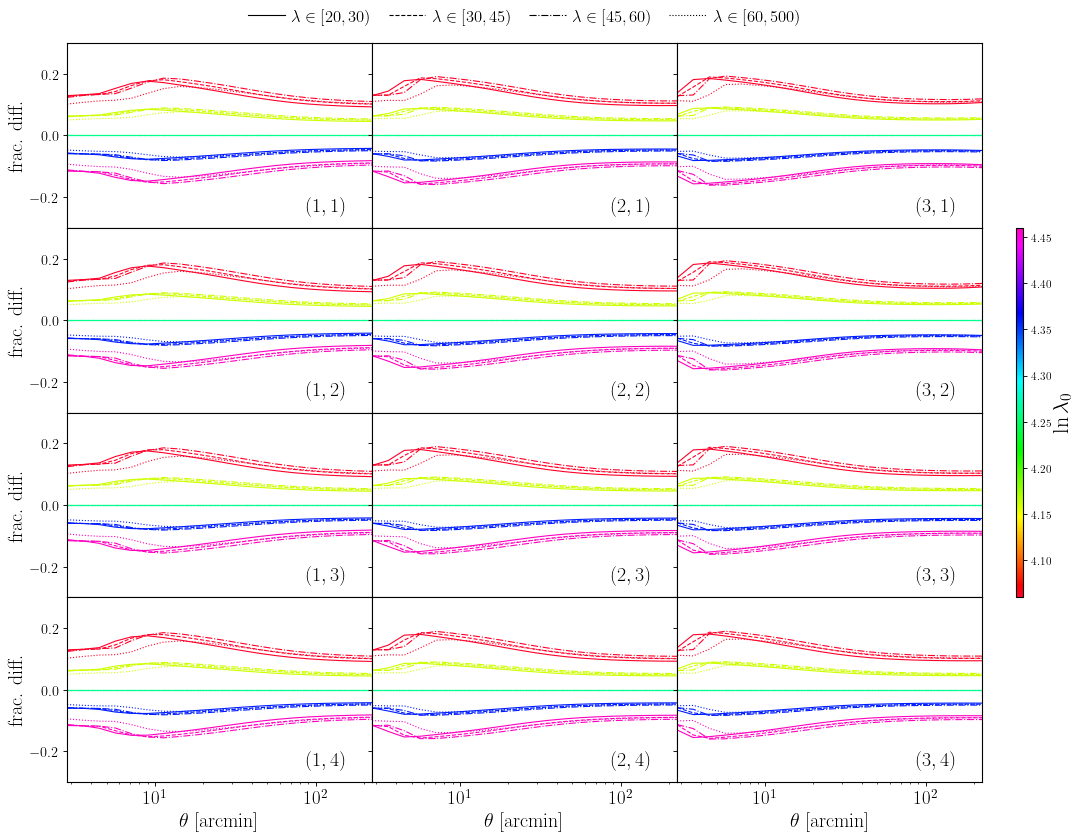

In [23]:
# gamma_t: the color is the parameter value, the line style the richness bin
pdc.plot_gammat_cluster_tomo(theta_gammat = gammat_param,
                             gammat_ref = theta_gammat,
                             param = param,
                             colorbarlabel = r"$\ln\lambda_0$",
                             richnesslabel = richness_label,
                             ylim = [0.7, 1.3],
                             figsize = (18, 12),
                             bintextpos = [0.85, 0.12],
                             bintextsize = 18,
                             yaxislabelsize = 18,
                             xaxislabelsize = 18,
                             yaxisticklabelsize = 13,
                             xaxisticklabelsize = 17)

## $\chi^2$ against the synthetic data vector

`nw.get_chi2` runs the likelihood's data-vector call. `nw.get_datavector` sets the complete interface state at the requested point; `ci.compute_data_vector_cluster_masked` assembles the 2812-entry theory vector $m$ in the block order `ss`, `gs`, `gg`, `cg`, `N`, `cc`, `cs`, with zeros at masked entries; and `ci.compute_chi2_cluster` returns
$$\chi^2=\sum_{i,j}(d_i-m_i)\,(C^{-1})_{ij}\,(d_j-m_j),$$
where $d$ is the synthetic data, $C$ the loaded covariance of the entries that the mask keeps, and the sum runs over those entries. At the fiducial point $\chi^2$ is small but not zero: the data were generated through Cobaya's CAMB run, while this notebook runs CAMB through `cnu.get_camb_cosmology` with its own sampling. The two shifted points show how strongly the 4x2pt + N data respond to $\Omega_m$ and to $\ln\lambda_0$.

In [24]:
# The synthetic data vector is the likelihood's model at the fiducial point
# (scripts/make_synthetic_data.py), so chi2 is small there; it is not
# exactly zero because this notebook's CAMB run is not the cobaya one.
print(r"$\chi^2$ (fiducial) = %.3e"%nw.get_chi2())
print(r"$\chi^2$ (omegam = 0.31) = %.3f"%nw.get_chi2(omegam=0.31))
print(r"$\chi^2$ (ln lambda_0 + 0.05) = %.3f"%nw.get_chi2(MOR=[DES_CL_LNLAMBDA0 + 0.05, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]))

$\chi^2$ (fiducial) = 1.330e-05


$\chi^2$ (omegam = 0.31) = 217.224


$\chi^2$ (ln lambda_0 + 0.05) = 87.021
